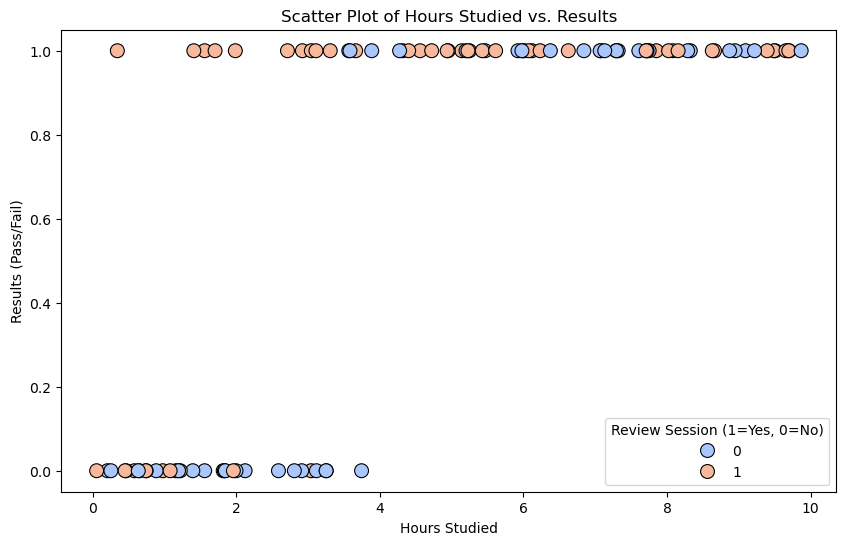

Coefficients: [[3.00072026 1.00361597]]
Intercept: [2.01522384]
Accuracy: 0.92
AUC: 0.98


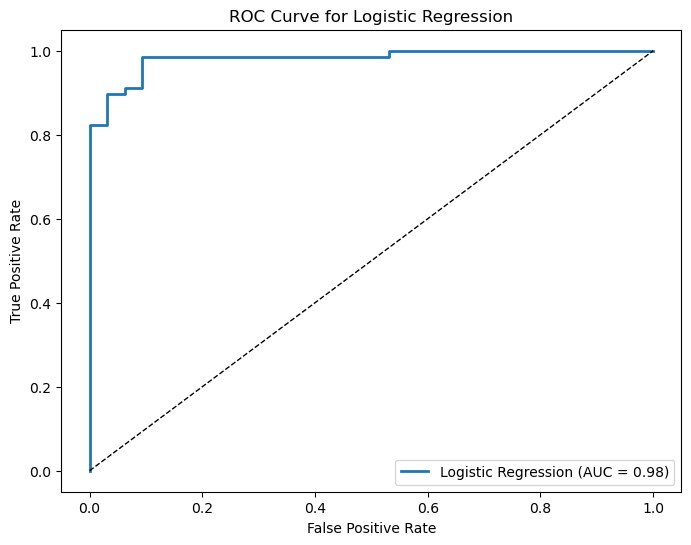

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\student_data.csv")

# Visualize the data
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Hours_Studied", y="Results", hue="Review_Session", palette="coolwarm", s=100, edgecolor="k")
plt.xlabel("Hours Studied")
plt.ylabel("Results (Pass/Fail)")
plt.title("Scatter Plot of Hours Studied vs. Results")
plt.legend(title="Review Session (1=Yes, 0=No)")
plt.show()

# Prepare data for Logistic Regression
X = df[['Hours_Studied', 'Review_Session']]
y = df['Results']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train the logistic regression model
log_reg = LogisticRegression()
log_reg.fit(X_scaled, y)

# Predict and evaluate the model
y_pred = log_reg.predict(X_scaled)
y_pred_prob = log_reg.predict_proba(X_scaled)[:, 1]

# Compute metrics
accuracy = accuracy_score(y, y_pred)
auc = roc_auc_score(y, y_pred_prob)
log_reg_coefficients = log_reg.coef_
log_reg_intercept = log_reg.intercept_

# Output results
print(f"Coefficients: {log_reg_coefficients}")
print(f"Intercept: {log_reg_intercept}")
print(f"Accuracy: {accuracy:.2f}")
print(f"AUC: {auc:.2f}")

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)  # Diagonal line for random guessing
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression")
plt.legend()
plt.show()


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Load the dataset
df = pd.read_csv(r"C:\Users\VAGBHAT\Downloads\student_data.csv")

# Prepare data for SVM
X = df[['Hours_Studied', 'Review_Session']]
y = df['Results']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train SVM with Linear Kernel
svm_linear = SVC(kernel='linear', probability=True)
svm_linear.fit(X_scaled, y)

y_pred_linear = svm_linear.predict(X_scaled)
y_pred_prob_linear = svm_linear.predict_proba(X_scaled)[:, 1]

accuracy_linear = accuracy_score(y, y_pred_linear)
auc_linear = roc_auc_score(y, y_pred_prob_linear)

print(f"SVM Linear Kernel - Accuracy: {accuracy_linear:.2f}, AUC: {auc_linear:.2f}")

# Train SVM with RBF Kernel and Hyperparameter Tuning (Gamma Search)
param_grid = {'gamma': np.logspace(-3, 3, 7)}  # Search from 0.001 to 1000
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_rbf = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=cv, scoring='accuracy')
svm_rbf.fit(X_scaled, y)

# Best gamma parameter
best_gamma = svm_rbf.best_params_['gamma']
print(f"Best Gamma for RBF Kernel: {best_gamma}")

# Model evaluation
y_pred_rbf = svm_rbf.best_estimator_.predict(X_scaled)
y_pred_prob_rbf = svm_rbf.best_estimator_.predict_proba(X_scaled)[:, 1]

accuracy_rbf = accuracy_score(y, y_pred_rbf)
auc_rbf = roc_auc_score(y, y_pred_prob_rbf)

print(f"SVM RBF Kernel - Accuracy: {accuracy_rbf:.2f}, AUC: {auc_rbf:.2f}")



SVM Linear Kernel - Accuracy: 0.91, AUC: 0.98
Best Gamma for RBF Kernel: 0.1
SVM RBF Kernel - Accuracy: 0.92, AUC: 0.98
